# Module 12 - Scaling Experiments

Use this notebook after you have saved at least one TinyStories model from Module 10. The main comparison here is intentionally narrow: `StoryLM-1M`, `StoryLM-5M`, and `StoryLM-30M` are all trained on TinyStories with the same tokenizer family, so changes in loss and samples are mostly about scale rather than corpus drift.

The notebook can train the small `StoryLM-1M` scaling anchor if it is missing. It expects `StoryLM-5M` and `StoryLM-30M` to come from Module 10, because those are longer payoff runs.

1. Read the lesson page (`docs/modules/12-scaling.md`).
2. Open this notebook with `./notebook.sh 12`.
3. Run the setup and artifact table cells.
4. Train `StoryLM-1M` only if it is missing.
5. Answer the inline prompts.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import math
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

import g2c
from g2c.artifacts import (
    available_model_artifacts,
    build_or_load_tokenized_corpus,
    load_model_artifact_with_tokenizer,
    load_run_state,
    model_artifact_exists,
    resolve_corpus,
    save_model_artifact,
)
from g2c.transformer import TransformerLM
from g2c.notebook_extras.pretraining import (
    make_tokenized_corpus_progress,
    plot_training_history,
    train_with_progress,
)
from g2c.notebook_extras.sampling import (
    plot_next_token_probabilities,
    show_model_samples,
)
from g2c.notebook_extras.scaling import (
    artifact_summary_rows,
    count_parameters,
    markdown_table,
    plot_compute_vs_loss,
    plot_loss_vs_params,
)

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
trainer_device = "auto"
print("MPS available:", torch.backends.mps.is_available())

MPS available: True


## Artifact Status

This module works best when `StoryLM-5M` and `StoryLM-30M` already exist from Module 10. `StoryLM-1M` is small enough that this notebook can create it as the low-end scaling point.

In [2]:
result = subprocess.run(
    [sys.executable, "scripts/artifact_status.py", "--module", "12"],
    cwd=repo_root,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

Course artifact status
repo: /Users/colkitt/sith/toys/courses/g2c

Dataset tracks
  ok Tiny     ./datasets.sh --tiny   100MB TinyStories + StoryTokenizer + tokenized StoryLM artifact
  ok Standard ./datasets.sh --small  GloVe + full TinyStories + small G2C corpus + tokenized artifacts
  ok Full     ./datasets.sh          GloVe + full TinyStories + full G2C corpus + tokenized artifacts

Datasets
  ok TinyShakespeare              (1.12MB)
  ok TinyStories 100MB            (100.00MB)
  ok TinyStories full             (1.92GB)
  ok G2C Corpus small             (1.01GB)
  ok G2C Corpus full              (9.01GB)
  ok GloVe 6B 50d                 (171.35MB)

Tokenizers
  ok ShakespeareTokenizer        
  ok StoryTokenizer              
  ok G2CTokenizer                

Tokenized corpora
  ok StoryLM TinyStories 100MB    (StoryLM-tinystories-100MB-v4096)
  ok StoryLM TinyStories full     (StoryLM-tinystories-full-v4096)
  ok TinyLLM G2C small            (TinyLLM-g2c-small-v8192)
  ok TinyLLM

## TinyStories Token Stream

The scaling comparison uses TinyStories only. If you have the full TinyStories corpus, the notebook uses it. If you only downloaded the tiny track, it uses the 100MB sample. Both paths use `StoryTokenizer` with an effective vocabulary of 4096.

In [3]:
tinystories_train_fraction = 0.9
tinystories_split_chunk_tokens = 100_000
tinystories_split_seed = 12
tinystories_requested_vocab_size = 4096
tinystories_tokenizer_name = "StoryTokenizer"
tinystories_tokenize_workers = os.cpu_count() or 1
tinystories_tokenize_chunk_bytes = 1_000_000

tinystories_full_spec = resolve_corpus("tinystories", repo_root=repo_root)
tinystories_sample_spec = resolve_corpus("tinystories-100MB", repo_root=repo_root)
tinystories_has_full = (
    tinystories_full_spec is not None
    and all(
        "100MB" not in shard.path.name
        for source in tinystories_full_spec.sources
        for shard in source.shards
    )
)

if tinystories_has_full:
    tinystories_corpus_name = "tinystories"
    tinystories_corpus_tag = "full"
    tinystories_source_label = "full TinyStories train split"
elif tinystories_sample_spec is not None:
    tinystories_corpus_name = "tinystories-100MB"
    tinystories_corpus_tag = "100MB"
    tinystories_source_label = "100MB TinyStories sample"
else:
    tinystories_corpus_name = "tinystories"
    tinystories_corpus_tag = "full"
    tinystories_source_label = "TinyStories train split"

vocab_tag = str(tinystories_requested_vocab_size)
tinystories_tokenized_corpus_name = f"StoryLM-tinystories-{tinystories_corpus_tag}-v{vocab_tag}"

tinystories_tokenized_corpus = None
tinystories_tokenizer = None
tinystories_train_ids = None
tinystories_val_ids = None
tinystories_vocab_size = None

try:
    tinystories_tokenized_corpus = build_or_load_tokenized_corpus(
        tinystories_tokenized_corpus_name,
        corpus=tinystories_corpus_name,
        tokenizer_name=tinystories_tokenizer_name,
        byte_count=None,
        source_split="train",
        vocab_size=tinystories_requested_vocab_size,
        repo_root=repo_root,
        chunk_bytes=tinystories_tokenize_chunk_bytes,
        workers=tinystories_tokenize_workers,
        progress_callback=make_tokenized_corpus_progress("TinyStories tokenized corpus"),
    )
except FileNotFoundError as exc:
    print("TinyStories artifacts are not ready yet.")
    print("Run `./datasets.sh --tiny` or `./datasets.sh --small`, then rerun this cell.")
    print(exc)
else:
    tinystories_pair = tinystories_tokenized_corpus.split(
        train_fraction=tinystories_train_fraction,
        chunk_tokens=tinystories_split_chunk_tokens,
        seed=tinystories_split_seed,
    )
    tinystories_tokenizer = tinystories_tokenized_corpus.tokenizer
    tinystories_train_ids = tinystories_pair.train
    tinystories_val_ids = tinystories_pair.val
    tinystories_vocab_size = tinystories_tokenizer.effective_vocab_size(
        tinystories_requested_vocab_size
    )
    print("TinyStories tokenized artifact:", tinystories_tokenized_corpus.artifact_dir.relative_to(repo_root))
    print("TinyStories total tokens:", len(tinystories_tokenized_corpus.tokens))
    print("TinyStories train tokens:", len(tinystories_train_ids))
    print("TinyStories valid tokens:", len(tinystories_val_ids))
    print("TinyStories effective vocab size:", tinystories_vocab_size)

TinyStories tokenized corpus: loaded existing tokenized corpus artifact.

TinyStories tokenized artifact: data/cache/token-corpus/StoryLM-tinystories-full-v4096
TinyStories total tokens: 368396988
TinyStories train tokens: 331596988
TinyStories valid tokens: 36800000
TinyStories effective vocab size: 4096


## Exercise 1 - Add the Low-End Scaling Point

`StoryLM-5M` and `StoryLM-30M` are the payoff models from Module 10. This cell adds a deliberately small `StoryLM-1M` anchor. It should be weak; its job is to make the scaling curve and sample-quality difference easier to see.

In [4]:
TRAIN_STORYLM_1M_IF_MISSING = True

storylm_1m_model_config = {
    "embedding_dim": 128,
    "num_layers": 4,
    "num_heads": 4,
    "max_seq_len": 256,
    "hidden_dim": 512,
}
storylm_1m_trainer_config = {
    "batch_size": 32,
    "context_length": 256,
    "max_steps": 5_000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 200,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 20,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
storylm_1m_checkpoint_path = repo_root / "data" / "work" / "module12" / "storylm-1m.ckpt"
storylm_1m_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

storylm_1m_model = None
storylm_1m_history = None

if model_artifact_exists("StoryLM-1M", repo_root=repo_root):
    print("StoryLM-1M already exists; skip training unless you intentionally delete or overwrite it.")
elif not TRAIN_STORYLM_1M_IF_MISSING:
    print("StoryLM-1M is missing and TRAIN_STORYLM_1M_IF_MISSING is False.")
elif tinystories_train_ids is None or tinystories_vocab_size is None:
    print("StoryLM-1M cannot train until TinyStories tokenized data is available.")
else:
    torch.manual_seed(12)
    storylm_1m_model = TransformerLM(
        vocab_size=tinystories_vocab_size,
        **storylm_1m_model_config,
    )
    print("StoryLM-1M params:", f"{count_parameters(storylm_1m_model):,}")
    storylm_1m_history = train_with_progress(
        "StoryLM 1M",
        storylm_1m_model,
        tinystories_train_ids,
        tinystories_val_ids,
        seed=12,
        checkpoint_path=storylm_1m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": storylm_1m_model_config,
            "vocab_size": tinystories_vocab_size,
            "tokenizer_artifact": tinystories_tokenizer_name,
        },
        **storylm_1m_trainer_config,
    )

StoryLM-1M params: 1,354,496
StoryLM 1M: starting fresh
StoryLM 1M params: 1,354,496
training device: mps


`[############################]` `5,000/5,000` | tokens `40.96M` | train loss `4.070` | val loss `4.100` | val ppl `60.4` | lr `3.00e-05` | grad norm `1.56` | elapsed `24.5 min` | tokens/s `27,861`

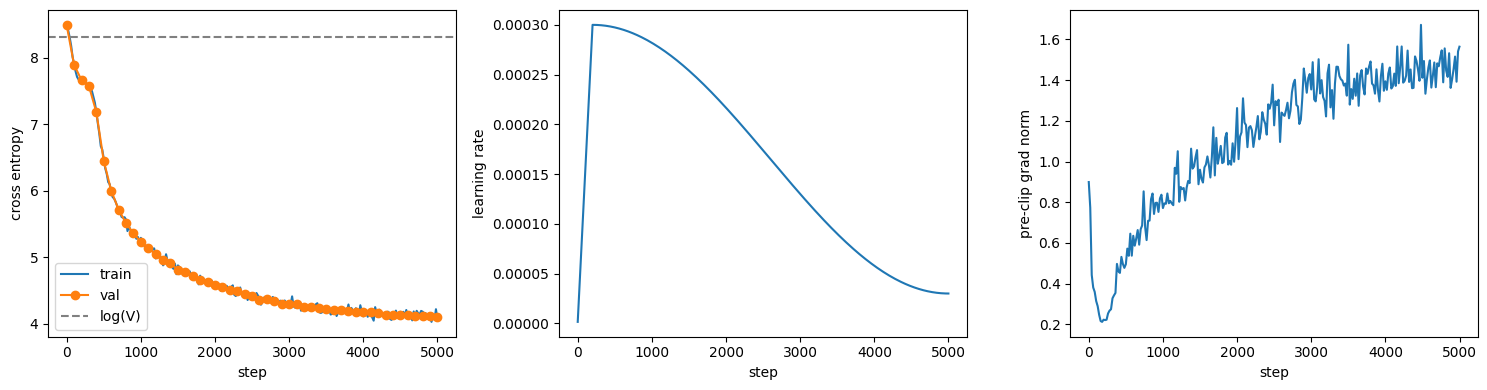

final train loss:     4.0701
final val loss:       4.1002
final val perplexity: 60.35


In [5]:
if storylm_1m_history is not None:
    plot_training_history(storylm_1m_history, baseline_loss=math.log(tinystories_vocab_size))
elif storylm_1m_checkpoint_path.exists():
    try:
        storylm_1m_model, storylm_1m_history = load_run_state(storylm_1m_checkpoint_path)
        print("loaded StoryLM-1M history from checkpoint")
        plot_training_history(storylm_1m_history, baseline_loss=math.log(storylm_1m_model.vocab_size))
    except Exception as exc:
        print("Could not load StoryLM-1M checkpoint:", exc)
else:
    print("No StoryLM-1M history to plot yet.")

In [6]:
if storylm_1m_model is not None and storylm_1m_history is not None:
    save_model_artifact(
        "StoryLM-1M",
        model=storylm_1m_model,
        model_config=storylm_1m_model_config,
        training_config=storylm_1m_trainer_config,
        tokenizer_artifact_name=tinystories_tokenizer_name,
        source=tinystories_source_label,
        history=storylm_1m_history,
        seed=12,
        notes="Module 12 -- low-end TinyStories scaling anchor.",
        repo_root=repo_root,
    )
    print("saved StoryLM-1M")
elif model_artifact_exists("StoryLM-1M", repo_root=repo_root):
    print("StoryLM-1M artifact already saved.")
else:
    print("Train StoryLM-1M before saving it.")

saved StoryLM-1M


## Exercise 2 - Compare the StoryLM Ladder

Now load the TinyStories family and inspect the actual run metadata. Missing rows are okay, but the clean three-point comparison is `StoryLM-1M`, `StoryLM-5M`, and `StoryLM-30M`.

In [7]:
story_scaling_names = ["StoryLM-1M", "StoryLM-5M", "StoryLM-30M"]
story_artifacts = []
missing_story_artifacts = []

for name in story_scaling_names:
    if model_artifact_exists(name, repo_root=repo_root):
        artifact = load_model_artifact_with_tokenizer(name, repo_root=repo_root, device="auto")
        story_artifacts.append(artifact)
    else:
        missing_story_artifacts.append(name)

if missing_story_artifacts:
    print("Missing StoryLM artifacts:", ", ".join(missing_story_artifacts))
    print("Run Module 10 for StoryLM-5M/30M, or train StoryLM-1M above if that is the missing point.")

story_rows = artifact_summary_rows(story_artifacts)
if story_rows:
    display(Markdown(markdown_table(story_rows)))
else:
    print("No StoryLM artifacts loaded yet.")

| model | params | vocab | layers | width | context | steps | tokens seen | val loss | val ppl |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| StoryLM-1M | 1.35M | 4096 | 4 | 128 | 256 | 5,000 | 40.96M | 4.100 | 60.4 |
| StoryLM-5M | 5.86M | 4096 | 6 | 256 | 256 | 30,000 | 122.88M | 2.563 | 13.0 |
| StoryLM-30M | 30.60M | 4096 | 9 | 512 | 256 | 12,001 | 24.58M | 2.740 | 15.5 |

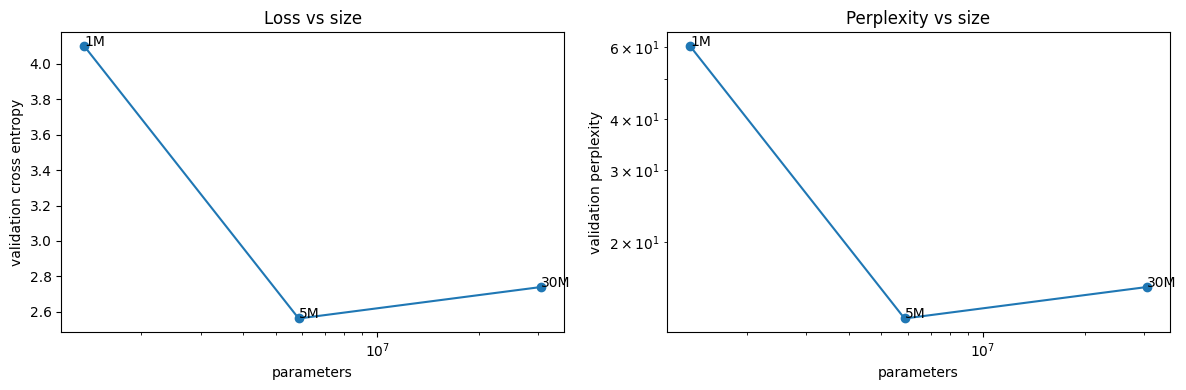

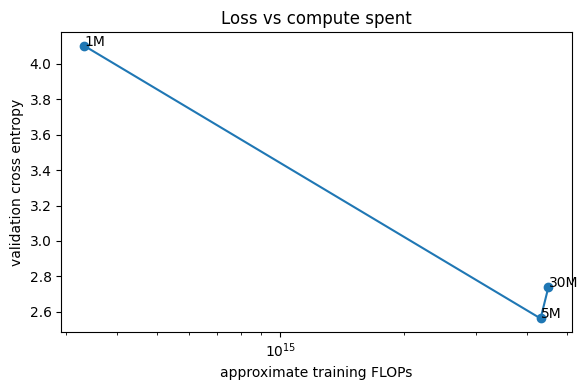

In [8]:
if story_rows:
    plot_loss_vs_params(story_rows)
    plot_compute_vs_loss(story_rows)
else:
    print("Load at least one StoryLM artifact first.")

In [9]:
Answer = ""
Question = "Why is the main scaling plot restricted to TinyStories models instead of mixing ShakespeareLM, StoryLM, and TinyLLM?"
print("Question:", Question)
print("Answer:", Answer)

Question: Why is the main scaling plot restricted to TinyStories models instead of mixing ShakespeareLM, StoryLM, and TinyLLM?
Answer: 


## Exercise 3 - Read the Samples

Loss curves are useful, but sample quality is the human-facing result. Use the same prompt and sampling settings for each model. The smaller model should usually have worse local grammar and less story-level continuity.

In [10]:
story_prompt = "Once upon a time,"
for index, artifact in enumerate(story_artifacts):
    print()
    print("=" * 80)
    print(artifact.display_name, f"({artifact.name})")
    print("=" * 80)
    show_model_samples(
        artifact.display_name,
        artifact.model,
        artifact.tokenizer,
        story_prompt,
        seed=12 + index,
    )



StoryLM 1M (StoryLM-1M)
StoryLM 1M raw sample, escaped so control bytes do not wreck notebook output
------------------------------------------------------------------------
Once upon a time, as it could spill and even make a wish. The dolhie was persisted that the deer could fly broken.\nSuddenly, a big bird went back to the lake. The bird. The bird was too scared and hopped out of the pond. But the bird was not could even faster and fast. The rabbit, the bird was allub its home. \nThe bird continued to gized and the bird never tried to find it. \nThe bird was amazed its home.\n<|endoftext|>\nOnce there was a little named Bob. He loved to explore, but when he saw the sunny day. One day, the man saw a bit magic. He quickly said "It. You can march it, I'll play together!" \nBob and Did officly took the iz on the big heart. From that day on, Bob learned an party away from what itely to stand a great idea.\n<|endoftext|>\nOnce upon a time, there was a big and dity frog. The hious. He lov

In [11]:
Answer = ""
Question = "Where do you first notice the larger model doing something the smaller model cannot do reliably? Name one concrete behavior from the samples."
print("Question:", Question)
print("Answer:", Answer)

Question: Where do you first notice the larger model doing something the smaller model cannot do reliably? Name one concrete behavior from the samples.
Answer: 


## Exercise 4 - Next-Token Distributions

The same prompt can reveal whether larger models place probability mass on more plausible continuations. This is not a benchmark; it is a quick way to connect logits, softmax probabilities, and sample quality.

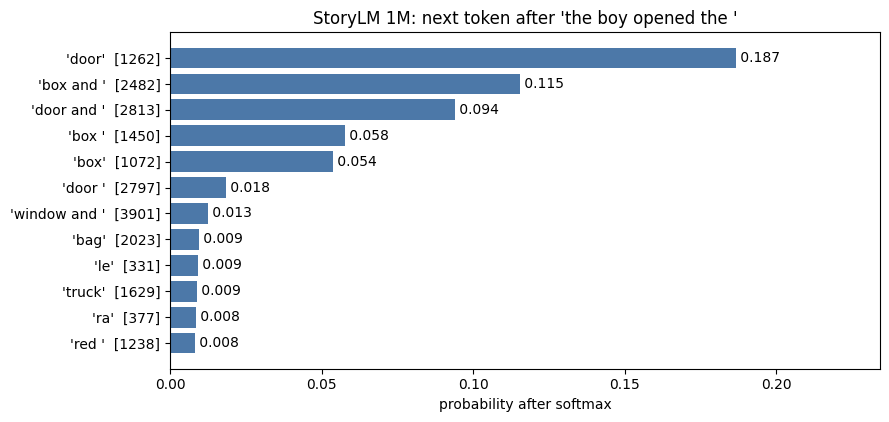

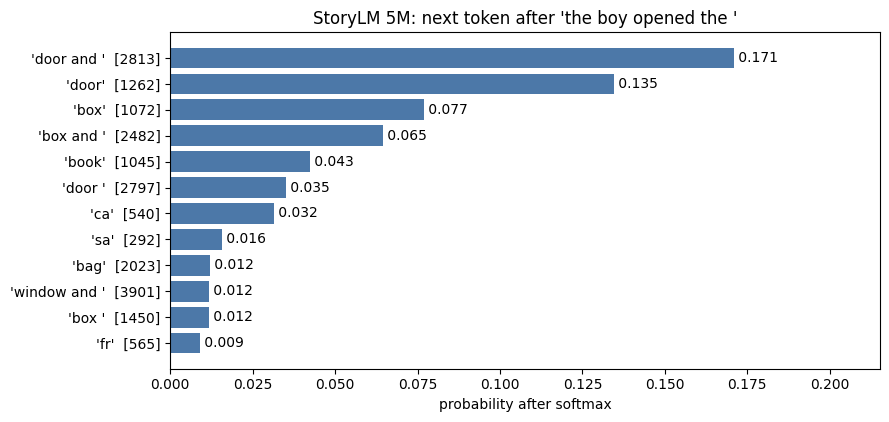

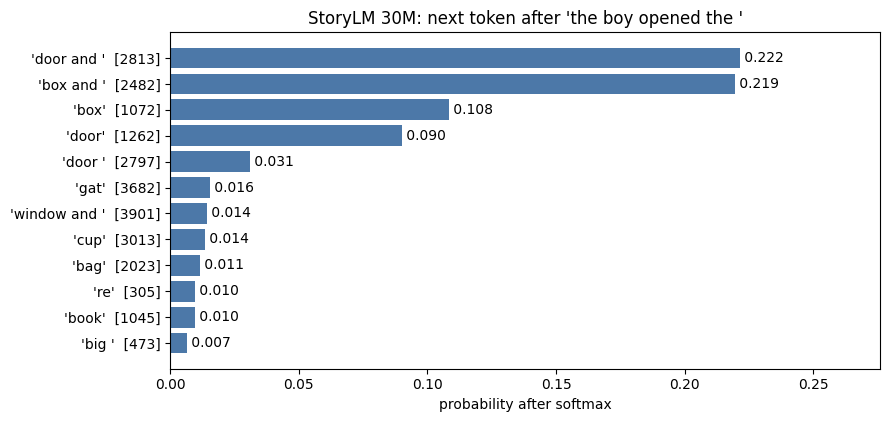

In [12]:
probe_prompt = "the boy opened the "
for artifact in story_artifacts:
    plot_next_token_probabilities(
        artifact.model,
        artifact.tokenizer,
        probe_prompt,
        n=12,
        temperature=1.0,
        title=f"{artifact.display_name}: next token after {probe_prompt!r}",
    )

In [13]:
Answer = ""
Question = "How does the next-token distribution change across model sizes? Is the largest model merely more confident, or does it put mass on qualitatively different tokens?"
print("Question:", Question)
print("Answer:", Answer)

Question: How does the next-token distribution change across model sizes? Is the largest model merely more confident, or does it put mass on qualitatively different tokens?
Answer: 


## Exercise 5 - Iso-Step versus Iso-FLOP

The artifact table includes approximate tokens seen and FLOPs. A larger model trained for the same number of steps spends more compute per step. That means a simple size-vs-loss curve is often an **iso-step** comparison, not an **iso-FLOP** comparison.

In [ ]:
if story_rows:
    print("model                    params      steps      tokens seen      approx FLOPs")
    print("-" * 78)
    for row in story_rows:
        print(
            f"{row['name']:<22}"
            f"{row['params']:>10,}  "
            f"{row['steps']:>8,}  "
            f"{(row['tokens_seen'] or 0):>14,}  "
            f"{(row['flops'] or 0):>14.3e}"
        )
else:
    print("Load StoryLM artifacts first.")

In [ ]:
Answer = ""
Question = "If the 30M model has lower loss, how much of that result is capacity and how much is extra compute? What would you change to make this closer to an iso-FLOP experiment?"
print("Question:", Question)
print("Answer:", Answer)

## Optional - Compare Against Other Artifacts

This is not part of the clean scaling curve, but it is useful context. `ShakespeareLM` and `TinyLLM` answer different questions because they use different corpora and possibly different tokenizer distributions.

In [ ]:
available = available_model_artifacts(repo_root=repo_root)
if available:
    print("available reusable artifacts:")
    for artifact in available:
        marker = "StoryLM scaling point" if artifact.canonical_name in story_scaling_names else "comparison only"
        print(f"  {artifact.display_name:<14} -> {artifact.name:<16} {marker}")
else:
    print("No reusable model artifacts found yet.")